# Лабораторна робота: Основи Data Science (NumPy, Pandas, Matplotlib)

У цій роботі ми розглянемо:

1. CRUD операції в NumPy.
2. Створення та аналіз DataFrame у Pandas.
3. Генерацію даних, візуалізацію та оцінювання похибок (MAE, MSE).

In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt

print("Бібліотеки успішно імпортовано!")

Бібліотеки успішно імпортовано!


## 1. Робота з NumPy (CRUD операції)

Ми створимо масиви, змінимо їх та видалимо елементи.

In [2]:
# CREATE 
linear_data = numpy.arange(0, 20, 2)
random_data = numpy.random.randint(0, 100, size=10)

print(f"Створено linear_data: {linear_data}")
print(f"Створено random_data: {random_data}")

# READ 
elem_3 = linear_data[3]
slice_data = random_data[:3]
print(f"\nЕлемент з індексом 3 (linear): {elem_3}")
print(f"Перші 3 елементи (random): {slice_data}")

# UPDATE
random_data[-1] = 999
linear_updated = linear_data * 10
print(f"\nОновлений random_data: {random_data}")
print(f"Масштабований linear_data: {linear_updated}")

# DELETE
random_deleted = numpy.delete(random_data, 0)
print(f"\nМасив після видалення першого елемента: {random_deleted}")

Створено linear_data: [ 0  2  4  6  8 10 12 14 16 18]
Створено random_data: [90  2 40 33 95 13 47 76 28 64]

Елемент з індексом 3 (linear): 6
Перші 3 елементи (random): [90  2 40]

Оновлений random_data: [ 90   2  40  33  95  13  47  76  28 999]
Масштабований linear_data: [  0  20  40  60  80 100 120 140 160 180]

Масив після видалення першого елемента: [  2  40  33  95  13  47  76  28 999]


## 2. Робота з Pandas

Створення DataFrame різними методами та базовий аналіз.

In [3]:
# --- Створення DataFrame ---

# Спосіб 1: З масиву NumPy
arr = numpy.random.randint(10, 50, size=(5, 3))
df_numpy = pd.DataFrame(arr, columns=['A', 'B', 'C'])

# Спосіб 2: Зі словника 
data_dict = {
    'Name': ['Anna', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [24, 19, 30, 45, 29],
    'Salary': [1200, 800, 2500, 3000, 1500]
}
df = pd.DataFrame(data_dict)

print("--- DataFrame зі словника ---")
display(df)

# Маніпуляції з даними 

print("\n--- Перші 2 рядки (head) ---")
display(df.head(2))

print("\n--- Статистичний опис (describe) ---")
display(df.describe())

print("\n--- Індексація ---")
print("loc (рядок 1, колонка 'Name'):", df.loc[1, 'Name'])

print("iloc (перші 2 рядки, колонки 0 і 1):\n", df.iloc[:2, 0:2])

--- DataFrame зі словника ---


,Name,Age,Salary
0,Anna,24,1200
1,Bob,19,800
2,Charlie,30,2500
3,David,45,3000
4,Eva,29,1500



--- Перші 2 рядки (head) ---


,Name,Age,Salary
0,Anna,24,1200
1,Bob,19,800



--- Статистичний опис (describe) ---


,Age,Salary
count,5.000000,5.000000
mean,29.400000,1800.000000
std,9.762172,919.238816
min,19.000000,800.000000
25%,24.000000,1200.000000
50%,29.000000,1500.000000
75%,30.000000,2500.000000
max,45.000000,3000.000000



--- Індексація ---
loc (рядок 1, колонка 'Name'): Bob
iloc (перші 2 рядки, колонки 0 і 1):
    Name  Age
0  Anna   24
1   Bob   19


## 3. Візуалізація та Метрики

Згенеруємо дані для лінійної функції $y = 2x + 5$ з додаванням випадкового шуму (похибки вимірювань).

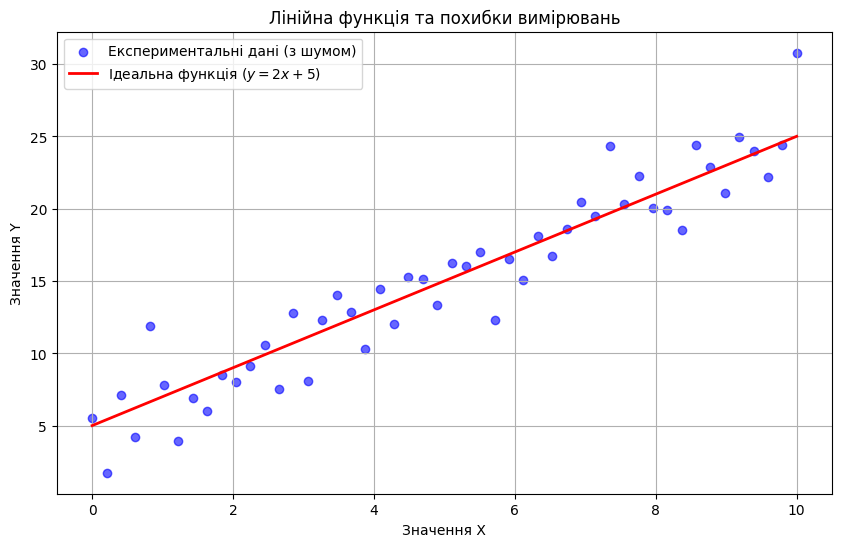

In [4]:
x = numpy.linspace(0, 10, 50)  # 50 точок від 0 до 10
true_slope = 2
true_intercept = 5

# Ідеальна функція: y = 2x + 5
y_true = true_slope * x + true_intercept

# Додаємо штучні похибки
noise = numpy.random.normal(0, 2, size=len(x)) # середнє 0, відхилення 2
y_measured = y_true + noise

# 2. Побудова графіка
plt.figure(figsize=(10, 6))

# Точки з даними (scatter plot)
plt.scatter(x, y_measured, color='blue', label='Експериментальні дані (з шумом)', alpha=0.6)

# Лінія ідеальної функції
plt.plot(x, y_true, color='red', linewidth=2, label='Ідеальна функція ($y=2x+5$)')

plt.title('Лінійна функція та похибки вимірювань')
plt.xlabel('Значення X')
plt.ylabel('Значення Y')
plt.legend()
plt.grid(True)
plt.show()

## 4. Обчислення похибок та Експорт

Ми оцінимо точність наших даних за допомогою метрик:
**MAE (Mean Absolute Error)** - середня абсолютна похибка.
**MSE (Mean Squared Error)** - середня квадратична похибка.

In [5]:
mae = numpy.mean(numpy.abs(y_true - y_measured))

mse = numpy.mean((y_true - y_measured) ** 2)

print(f"MAE (Середня абсолютна похибка): {mae:.4f}")
print(f"MSE (Середня квадратична похибка): {mse:.4f}")

# Запис у CSV 

# Створюємо фінальний DataFrame для звіту
results_df = pd.DataFrame({
    'X': x,
    'Y_True': y_true,
    'Y_Measured': y_measured,
    'Error': y_measured - y_true
})

filename = 'experiment_results.csv'
results_df.to_csv(filename, index=False)

print(f"\nРезультати успішно збережено у файл '{filename}'")
display(results_df.head())

MAE (Середня абсолютна похибка): 1.6358
MSE (Середня квадратична похибка): 4.4832

Результати успішно збережено у файл 'experiment_results.csv'


,X,Y_True,Y_Measured,Error
0,0.000000,5.000000,5.529313,0.529313
1,0.204082,5.408163,1.741922,-3.666241
2,0.408163,5.816327,7.090016,1.273689
3,0.612245,6.224490,4.191387,-2.033103
4,0.816327,6.632653,11.902357,5.269704
